# Audio Processing 기본

In [1]:
# 실습 전 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display
import torchaudio
import IPython.display as ipd

## 위상 (Phase)
- <ins>**파동의 한 주기에서 첫 시작점의 각도 혹은 한 시점의 위치**</ins>
- 위상 변화는 파동의 시작점을 바꾸며, 이는 <ins>**신호의 시간적 변동성에 영향을 미침**</ins>

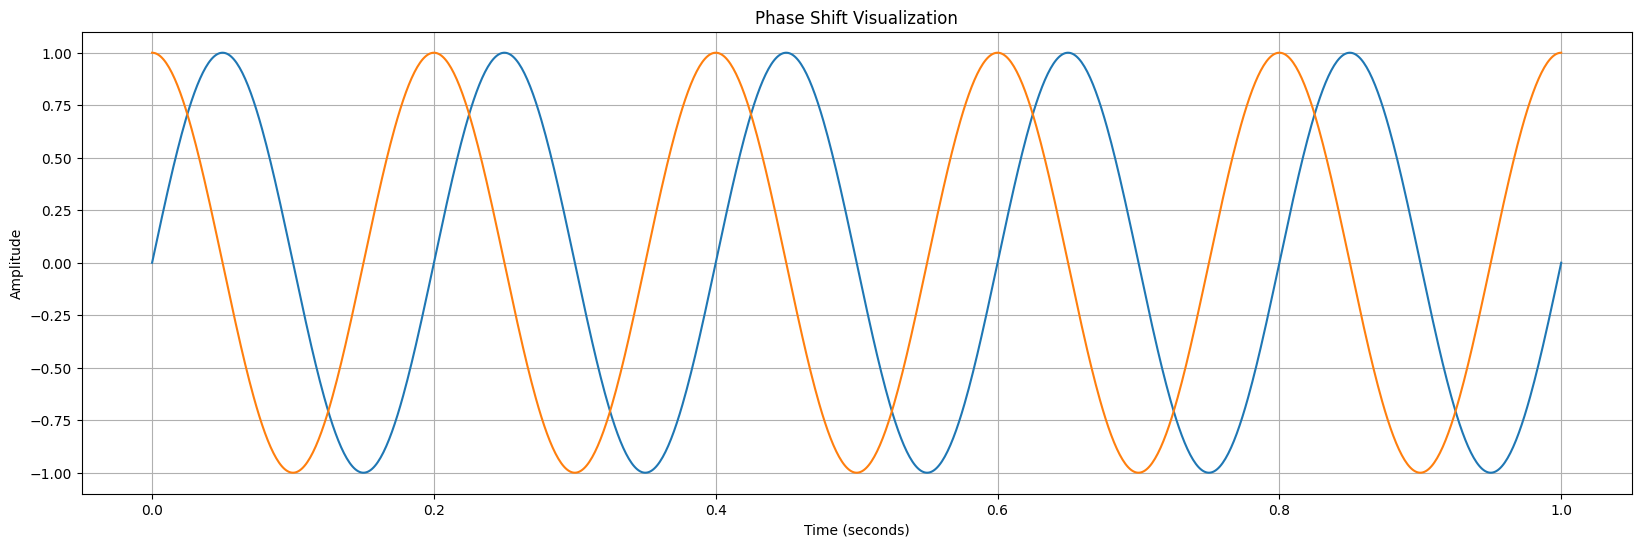

In [2]:
# 위상
# 시간축을 설정합니다: 0에서 1초까지, 총 1000개의 데이터 포인트
t = np.linspace(0, 1, 1000)

# 주파수를 설정합니다 (예: 5 Hz)
frequency = 5

# 두 개의 신호를 생성합니다. 하나는 위상이 0도, 다른 하나는 90도 시프트된 신호입니다.
signal_1 = np.sin(2 * np.pi * frequency * t)
signal_2 = np.sin(2 * np.pi * frequency * t + np.pi/2)  # 위상이 90도 시프트

# 신호를 그래프로 그립니다.
plt.figure(figsize=(20, 6))
plt.plot(t, signal_1)
plt.plot(t, signal_2, label='phase = 90°')
plt.title('Phase Shift Visualization')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
# plt.legend()
plt.grid(True)
plt.show()

## 진폭 (Amplitude)
- <ins>**파동의 주기에서 파동의 가운데로부터 최대로 움직인 값**</ins>
- <ins>**진폭이 클 수록**</ins> 파동의 최대 및 최소 값이 더 크게 나타나고, 이는 <ins>**소리의 크기가 더 크다는 것**</ins>을 의미

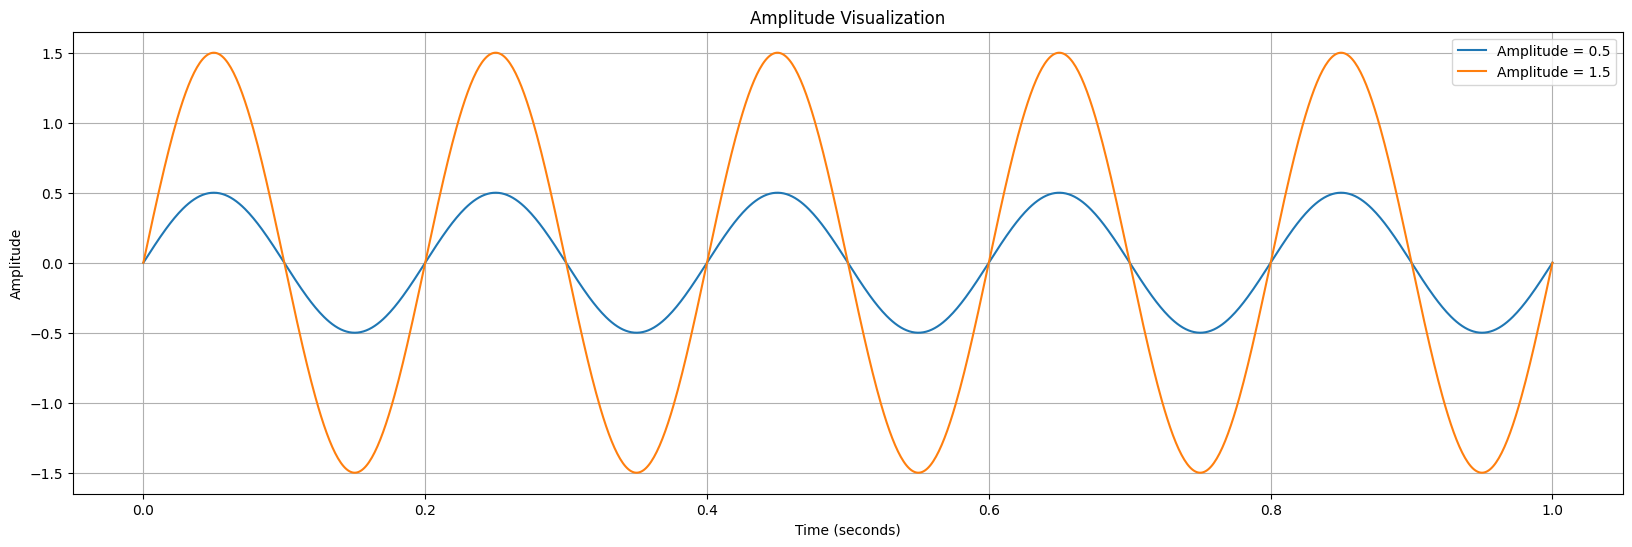

In [3]:
# 진폭
# 시간축 설정: 0에서 1초까지, 총 1000개의 데이터 포인트
t = np.linspace(0, 1, 1000)

# 주파수를 설정합니다 (예: 5 Hz)
frequency = 5

# 서로 다른 진폭을 가진 두 개의 신호 생성
signal_1 = 0.5 * np.sin(2 * np.pi * frequency * t)  # 진폭 0.5
signal_2 = 1.5 * np.sin(2 * np.pi * frequency * t)  # 진폭 1.5

# 신호를 그래프로 그립니다.
plt.figure(figsize=(20, 6))
plt.plot(t, signal_1, label='Amplitude = 0.5')
plt.plot(t, signal_2, label='Amplitude = 1.5')
plt.title('Amplitude Visualization')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

## 주파수 (Frequency)
- <ins>**단위 시간당 파동이 반복되는 횟수**</ins> (단위: Hz)
- <ins>**주파수가 높을수록 소리가 높게**</ins> 들리고,<ins>**주파수가 낮을수록 소리가 낮게**</ins> 들림

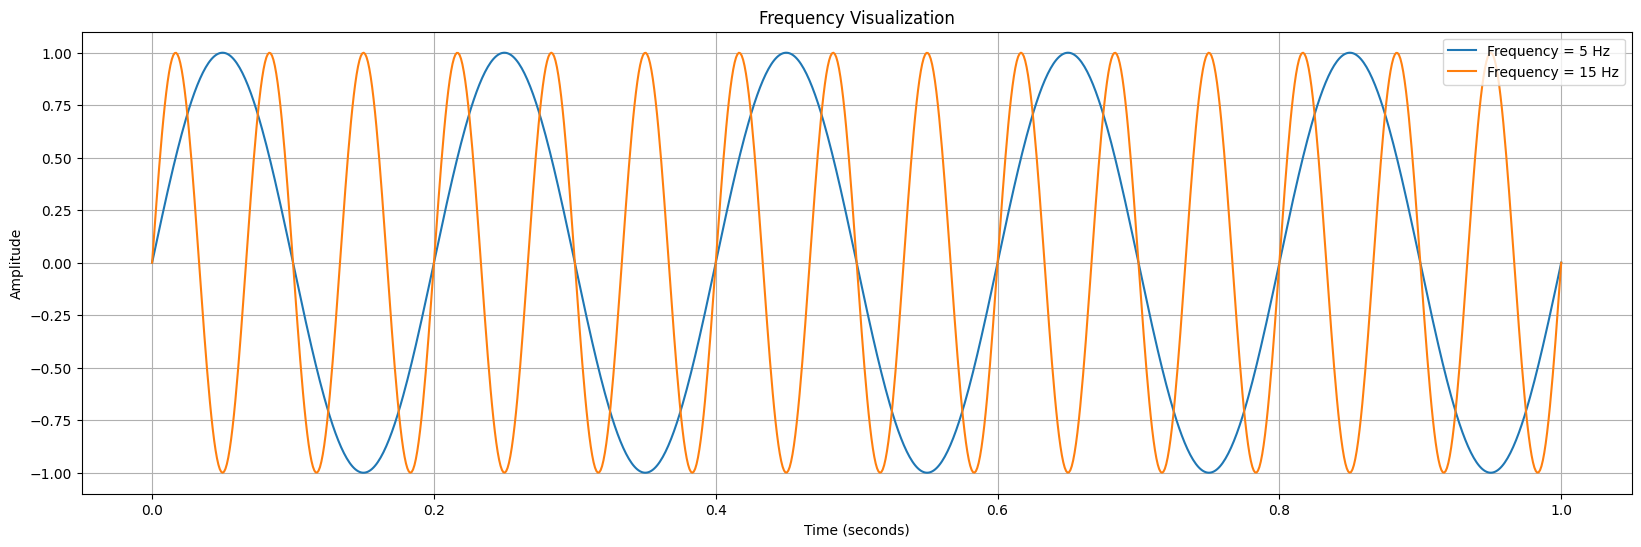

In [4]:
# 주파수
# 시간축 설정: 0에서 1초까지, 총 1000개의 데이터 포인트
t = np.linspace(0, 1, 1000)

# 서로 다른 주파수를 가진 두 개의 신호 생성
signal_1 = np.sin(2 * np.pi * 5 * t)  # 주파수 5 Hz
signal_2 = np.sin(2 * np.pi * 15 * t)  # 주파수 15 Hz

# 신호를 그래프로 그립니다.
plt.figure(figsize=(20, 6))
plt.plot(t, signal_1, label='Frequency = 5 Hz')
plt.plot(t, signal_2, label='Frequency = 15 Hz')
plt.title('Frequency Visualization')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

## 샘플링 (Sampling)
- 아날로그 신호를 디지털 신호로 바꿀 때, <ins>**어떤 기준에서 아날로그 정보를 나누고, 나누었을 때의 대표값을 사용**</ins>하는 것
- 샘플링 레이트(Sampling rate): <ins>**1초를 기준으로 몇 번의 샘플을 취할지**</ins> 나타내는 단위 (단위: Hz)
- 오디오 CD: 44.1 kHz(44,100 샘플 / 초), 통화: 8, 16kHz(8,000, 16,000 샘플 / 초)
- 비트 뎁스 (Bit depth): 각 <ins>**샘플을 저장하는데 사용되는 비트 수**</ins>
    - 8비트: 신호 대 잡음비가 낮아 잡음이 많이 발생
    - 16비트: CD나 MP3 등에서 흔히 사용되는 방식으로 8비트에 비해 깨끗한 소리
    - 24비트: 일반적으로 16비트와 구분하기 어려우나 <ins>**클리핑 현상을 방지하고 왜곡없이 정확한 신호를 기록**</ins> 할 수 있음 <br> 클리핑현상: 오디오의 진폭이 높아 <ins>**비트의 표현범위를 벗어나 소리가 잘려 나가는**</ins> 현상
    - 32비트: <ins>**전문적인 오디오 제작이나 고품질의 레코딩**</ins>에서 사용
- 파일크기 = "<ins>**Bit depth**</ins>" X "<ins>**Sampling rate**</ins>" X "<ins>**Time**</ins>" <br> ex.) 16bit X 44.1kHz X 60sec = 5.3MB
- 데시벨 (decibel, dB): 절대값이 아닌 <ins>**상대값**</ins>으로, <ins>**소리의 강도를 나타내는 단위**</ins> $$\text{dB} = 20 \times \log_{10} \left(\frac{V_B}{V_A}\right)$$
- 동적 범위 (dynamic range): <ins>**최소 출력과 최대 출력의 비**</ins>


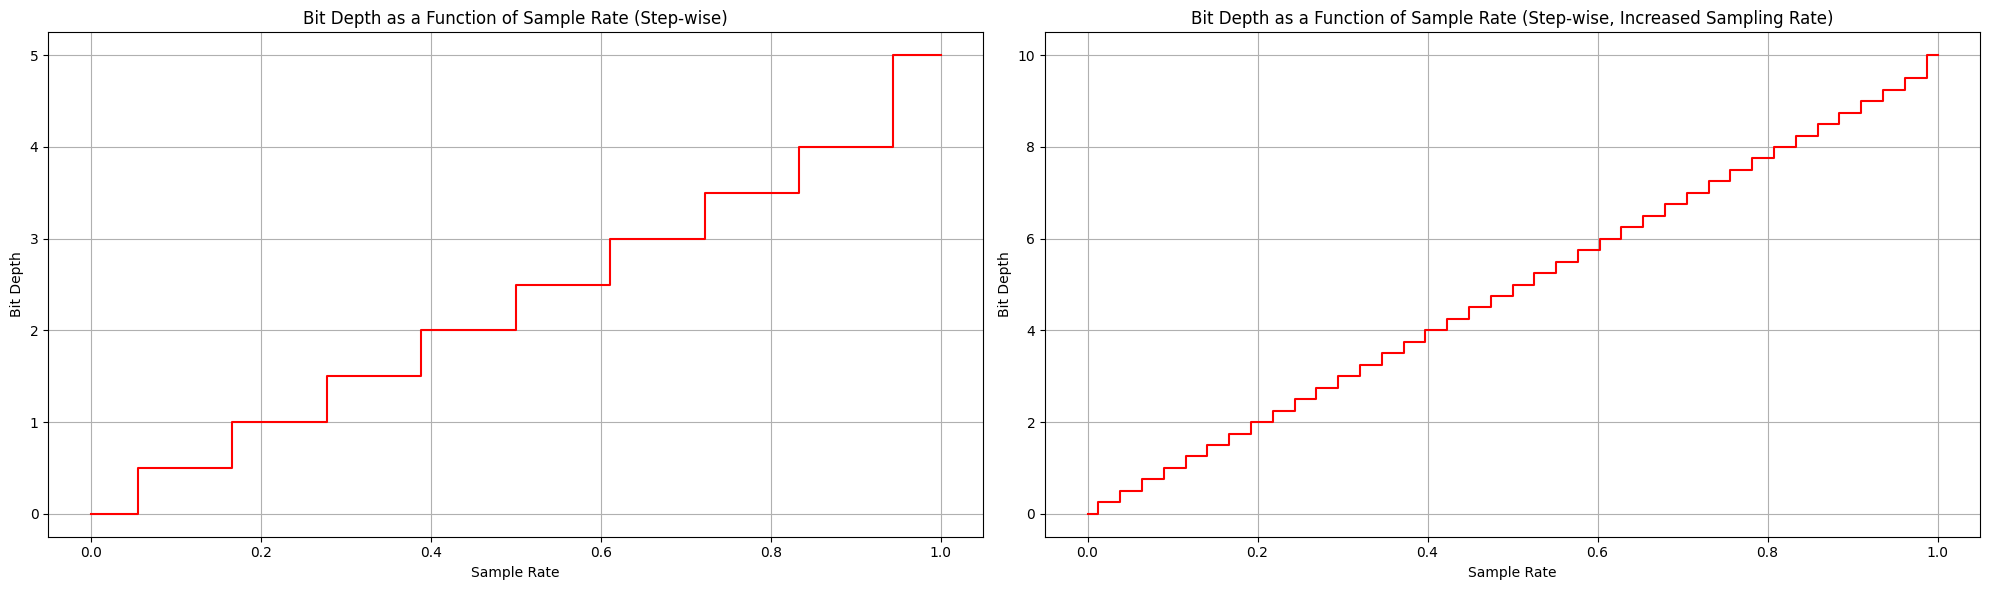

In [5]:
# sampling rate
# 계단식 그래프 데이터를 수정하여 두 번째 그래프도 계단식으로 변경하고, 샘플링 레이트 범위를 2배 늘림

# 첫 번째 계단식 그래프 데이터
x_steps_1 = np.linspace(0, 1, 10)
y_steps_1 = np.floor(np.linspace(0, 1, 10) * 10) / 2  # Bit depth 예제 값

# 두 번째 계단식 그래프 데이터 (샘플링 레이트 4배 증가)
x_steps_2 = np.linspace(0, 1, 40)
y_steps_2 = np.floor(np.linspace(0, 1, 40) * 40) / 4  # Bit depth 예제 값

# 시각화
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.step(x_steps_1, y_steps_1, where='mid', label='Step-wise Change', color='red')
plt.title('Bit Depth as a Function of Sample Rate (Step-wise)')
plt.xlabel('Sample Rate')
plt.ylabel('Bit Depth')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.step(x_steps_2, y_steps_2, where='mid', label='Step-wise Change', color='red')
plt.title('Bit Depth as a Function of Sample Rate (Step-wise, Increased Sampling Rate)')
plt.xlabel('Sample Rate')
plt.ylabel('Bit Depth')
plt.grid(True)

plt.tight_layout()
plt.show()

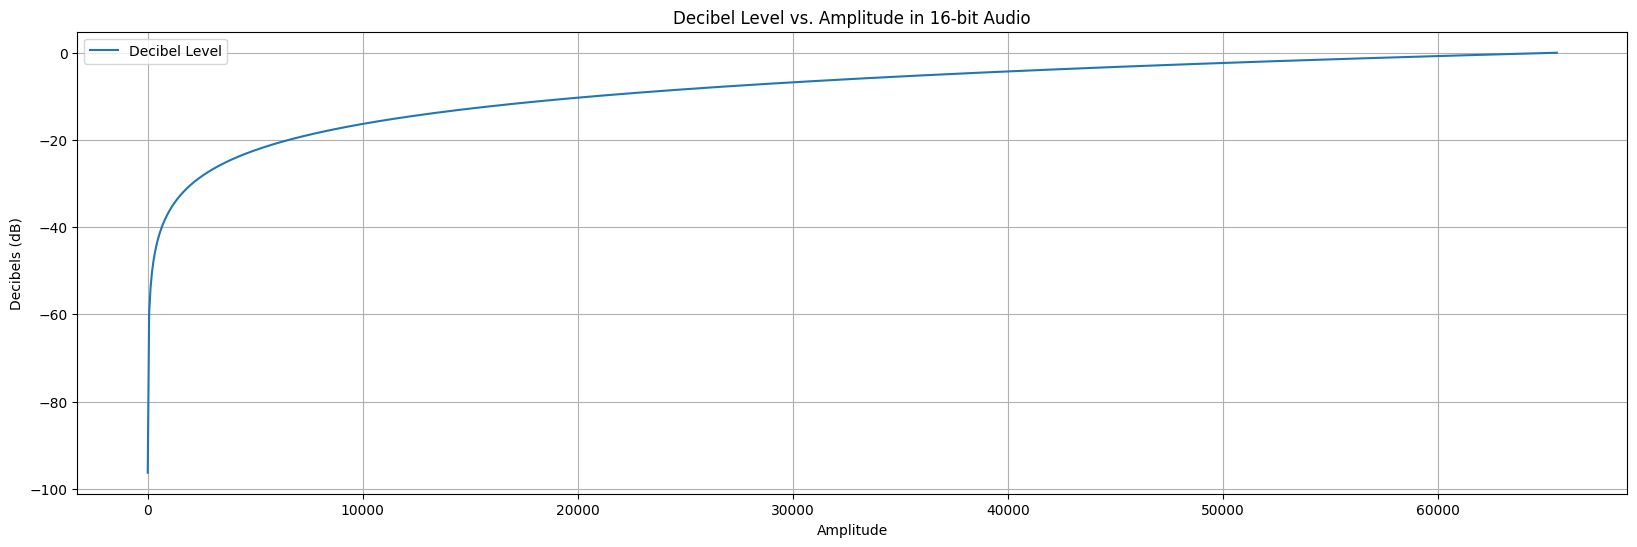

In [6]:
# 데시벨
# 16비트 최대 진폭 설정
max_amplitude = 2**16 - 1

# 진폭 범위 생성 (0부터 최대 진폭까지)
amplitudes = np.linspace(1, max_amplitude, 1000)  # 0을 제외하여 log 계산 가능하게 함

# 데시벨 계산
decibels = 20 * np.log10(amplitudes / max_amplitude)

# 그래프 그리기
plt.figure(figsize=(20, 6))
plt.plot(amplitudes, decibels, label="Decibel Level")
plt.title("Decibel Level vs. Amplitude in 16-bit Audio")
plt.xlabel("Amplitude")
plt.ylabel("Decibels (dB)")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# 샘플 데이터 가져오기
dataset = torchaudio.datasets.LIBRISPEECH("./", url="test-clean", download=True)

100%|██████████| 331M/331M [00:09<00:00, 37.4MB/s]


In [8]:
# 샘플데이터 구조 확인
dataset[2]

(tensor([[ 0.0004,  0.0006,  0.0008,  ..., -0.0001, -0.0004, -0.0007]]),
 16000,
 'AFTER EARLY NIGHTFALL THE YELLOW LAMPS WOULD LIGHT UP HERE AND THERE THE SQUALID QUARTER OF THE BROTHELS',
 1089,
 134686,
 2)

In [9]:
# 샘플데이터 들어보기
audio_data = dataset[2][0][0]
sr = dataset[2][1]

print(audio_data.shape, sr)
print('length: ', len(audio_data))
print('duration: ', len(audio_data) / sr)

ipd.Audio(audio_data, rate=sr)

torch.Size([106000]) 16000
length:  106000
duration:  6.625


In [10]:
# 샘플데이터 8k로 resampling
audio_np = audio_data.numpy()
y_8k = librosa.resample(audio_np, orig_sr=sr, target_sr=8000)

ipd.Audio(y_8k, rate=8000)

In [11]:
# 샘플데이터 4k로 resampling
y_4k = librosa.resample(audio_np, orig_sr=sr, target_sr=4000)

ipd.Audio(y_4k, rate=4000)

In [12]:
# Bit depth를 8비트로 Quantization
bit = 8
max_value = 2 ** (bit - 1)

quentized_4_wav = audio_np * max_value
quentized_4_wav = np.round(quentized_4_wav).astype(int)
quentized_4_wav = np.clip(quentized_4_wav, -max_value, max_value)
ipd.Audio(quentized_4_wav, rate=sr)

## 오디오 표현 (Audio Representation)
- 오디오 표현은 <ins>**Time-domain representation**</ins>과 <ins>**Time-frequency representation**</ins>
- Time-domain representation: 오디오 신호나 다른 유형의 <ins>**신호를 시간에 따른 진폭 변화로 표현**</ins>하는 방법
- Time-domain representation은 시간에 따른 진폭만을 표현하기 때문에 <ins>**주파수에 대한 정보를 알기 어려움**</ins>


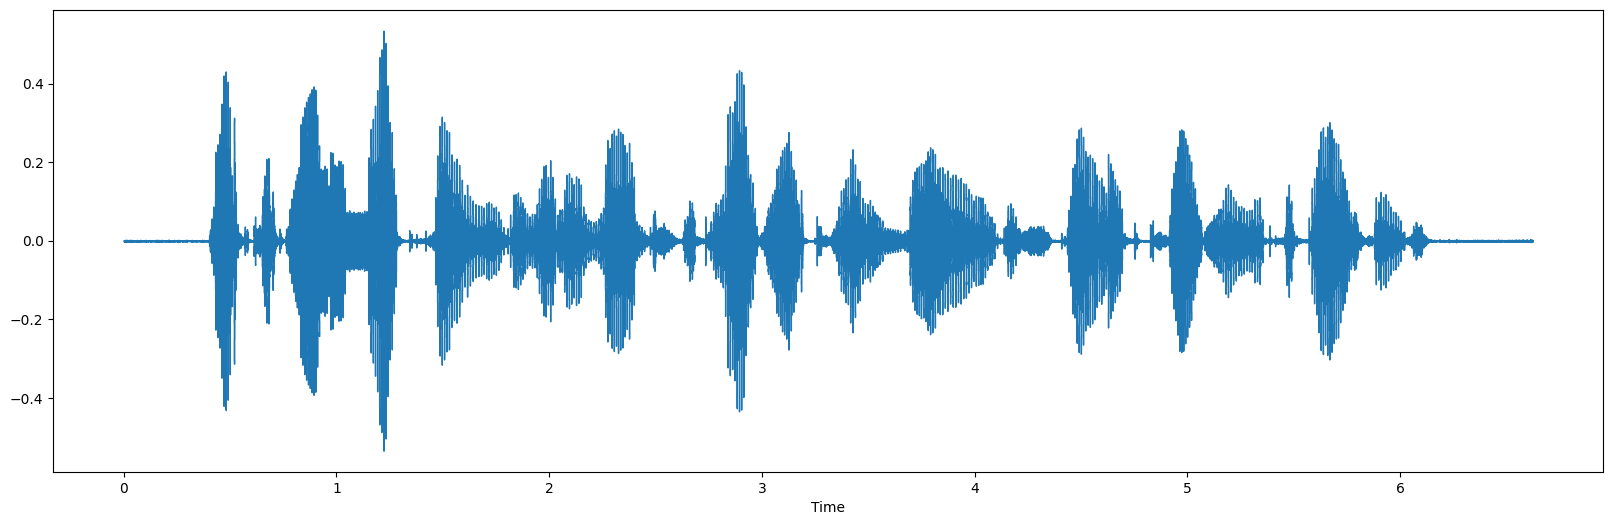

In [13]:
# Time-domain representation 웨이브폼 출력하기
fig = plt.figure(figsize=(20, 6))
librosa.display.waveshow(audio_np, sr=sr)

- Time-frequency representation: 오디오 신호의 <ins>**시간에 따른 주파수**</ins>를 분석하고 시각화하는 방법
- 푸리에 변환: <ins>**모든 신호는 여러 개의 주기함수의 조합**</ins>으로 나타낼 수 있음
- Spectrum: Time-domain representation을 <ins>**푸리에 변환**</ins>을 통해 여러 개의 주파수(주기함수)로 표현하고 <ins>**주파수에 따른 규모를 시각화**</ins>하여 나타낸 것
- Spectrum은 <ins>**주파수 도메인의 신호를 시간 축과 무관**</ins>하게 표현

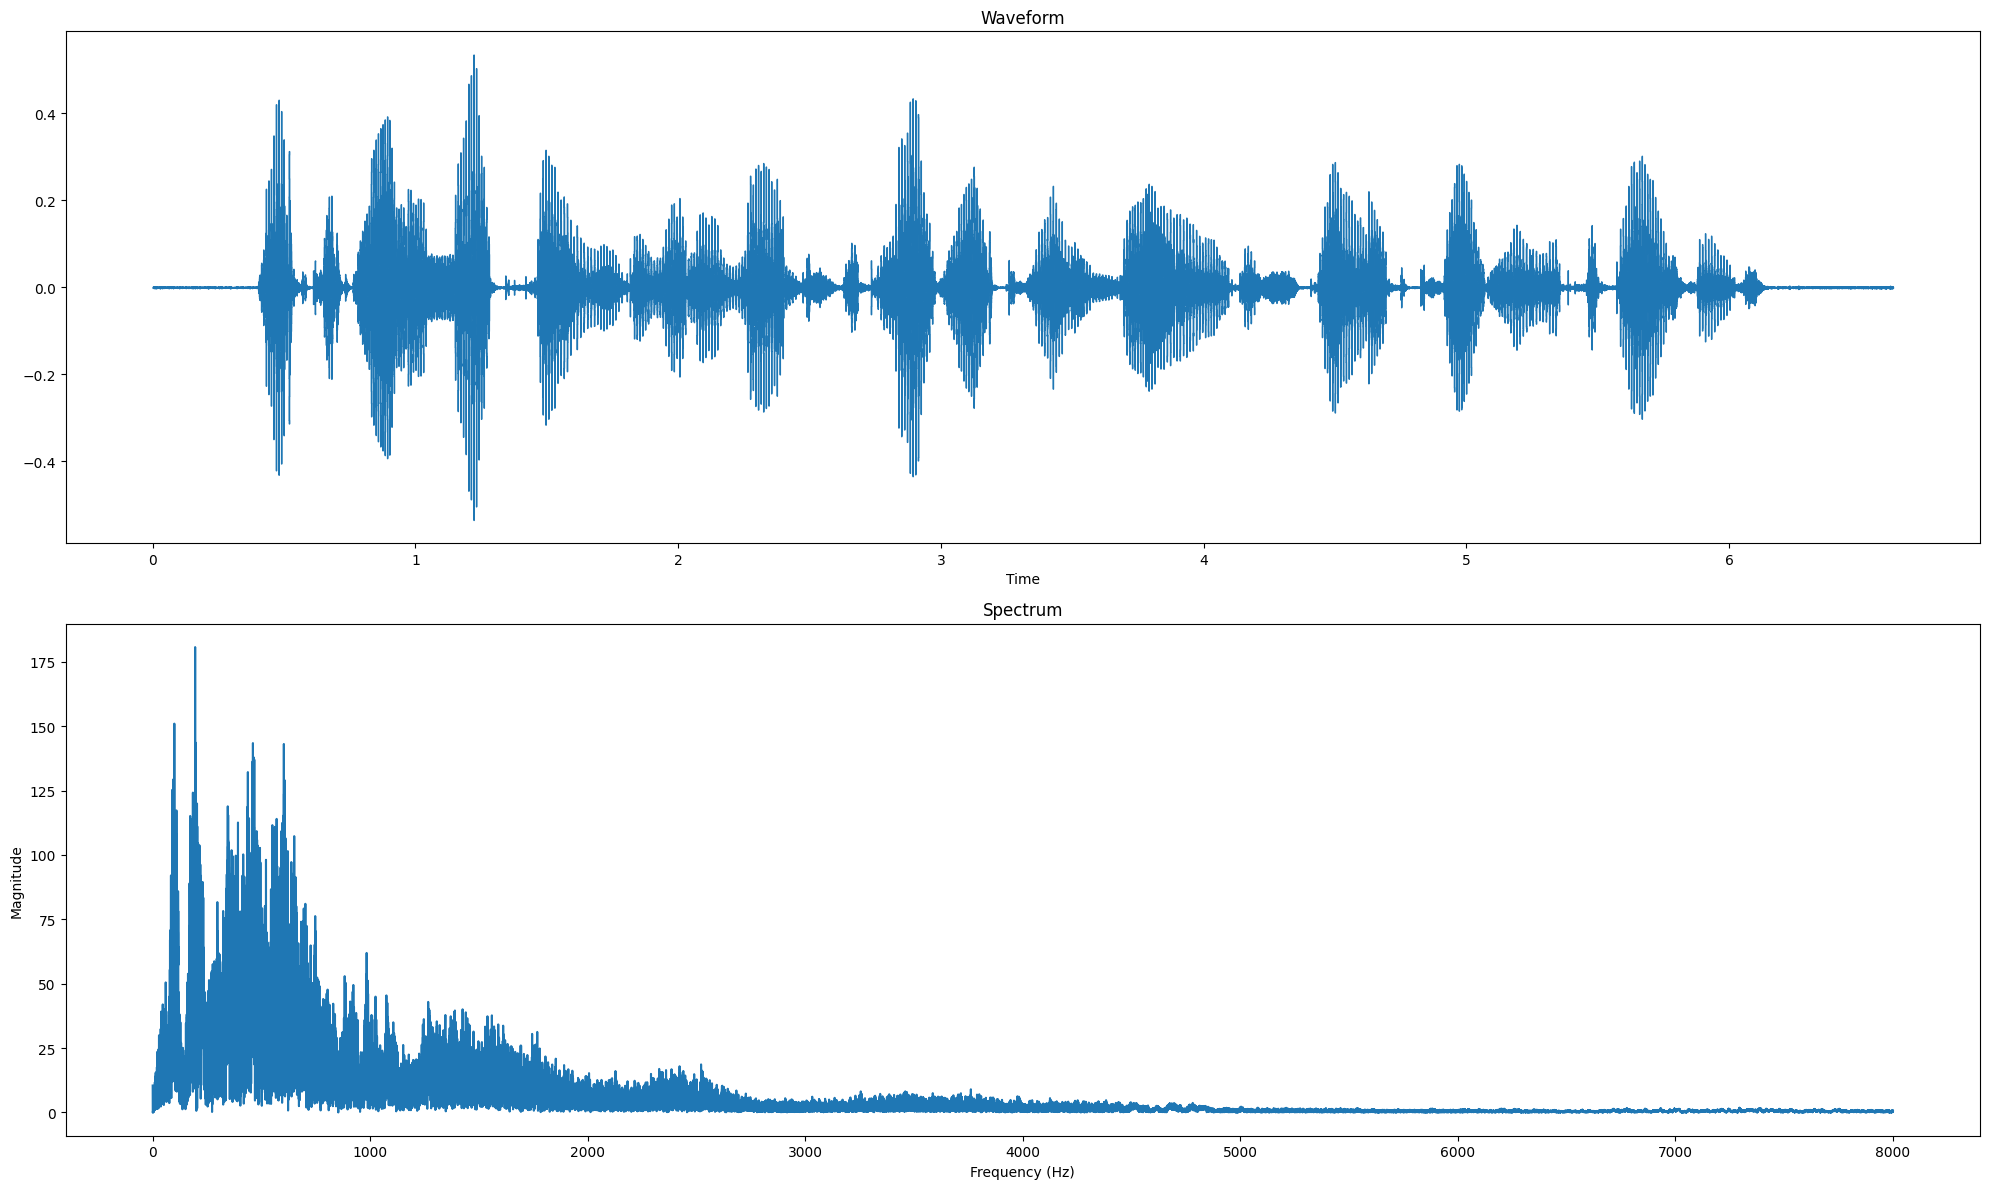

In [14]:
# 푸리에 변환

# 푸리에 변환 수행
fft_result = np.fft.fft(audio_np)
fft_magnitude = np.abs(fft_result)

# 주파수 축 생성
frequency = np.linspace(0, sr, len(fft_magnitude))

# 웨이브폼을 표시하는 플롯 생성
fig, ax = plt.subplots(2, 1, figsize=(20, 12))

# 첫 번째 서브플롯에 웨이브폼 표시
librosa.display.waveshow(audio_np, sr=sr, ax=ax[0])
ax[0].set_title('Waveform')

# 두 번째 서브플롯에 스펙트럼 표시
ax[1].plot(frequency[:len(frequency)//2], fft_magnitude[:len(frequency)//2])  # 나일론 주파수 범위까지 표시
ax[1].set_title('Spectrum')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Magnitude')

plt.tight_layout()
plt.show()

- Spectrogram: 시간에 따라 변화하는 <ins>**연속된 Spectrum**</ins>
- STFT(Short-Time Fourier Transform): <ins>**신호를 짧은 시간 구간**</ins>으로 나누고, 각 <ins>**구간에 대해 푸리에 변환을 적용**</ins>하는 과정
- Window size: 입력된 신호를 분석하기 위해 <ins>**나눈 구간의 길이**</ins>를 의미
- Hop size: <ins>**구간과 구간사이의 겹치는 길이**</ins>를 의미
- Window function: 입력 데이터를 임의의 구간으로 나눌 때 발생하는 <ins>**연속성이 무너지는 현상을 보완하기 위해 구간의 양 끝을 0으로 맞추기 위한 함수**</ins>
- STFT의 단계
    1. 입력신호를 <ins>**작은 시간단위**</ins>로 나눔
    2. 각 구간에 <ins>**Window function**</ins>을 적용
    3. 각 구간에 <ins>**푸리에 변환을 수행**</ins>하여 Spectrum 생성
    4. <ins>**시간에 따른 주파수의 변화**</ins>로 시각화 (Spectrogram)

In [15]:
# window 단위로 자르기
def frame_audio(audio, window_size_ms=25, hop_size_ms=10, sample_rate=16000):
    audio = np.pad(audio, int(window_size_ms / 2), mode='reflect')  # 오디오 데이터 양 끝에 'reflect' 모드로 패딩을 추가하여 경계 문제를 방지

    # window_size 및 hop_size를 밀리초에서 샘플 수로 변환
    window_size = int(window_size_ms * sample_rate / 1000)
    hop_size = int(hop_size_ms * sample_rate / 1000)

    # 총 프레임 수 계산
    frame_num = 1 + int((len(audio) - window_size) / hop_size)

    # 프레임 저장을 위한 numpy 배열 초기화
    frames = np.zeros((frame_num, window_size))

    # 프레임 단위로 신호를 나누어 배열에 저장
    for i in range(frame_num):
        start_index = i * hop_size
        frames[i, :] = audio[start_index:start_index + window_size]

    return frames


audio_framed = frame_audio(audio_np)

print("Original audio length: {}".format(len(audio_np)))
print("Framed audio shape: {}".format(audio_framed.shape))

Original audio length: 106000
Framed audio shape: (661, 400)


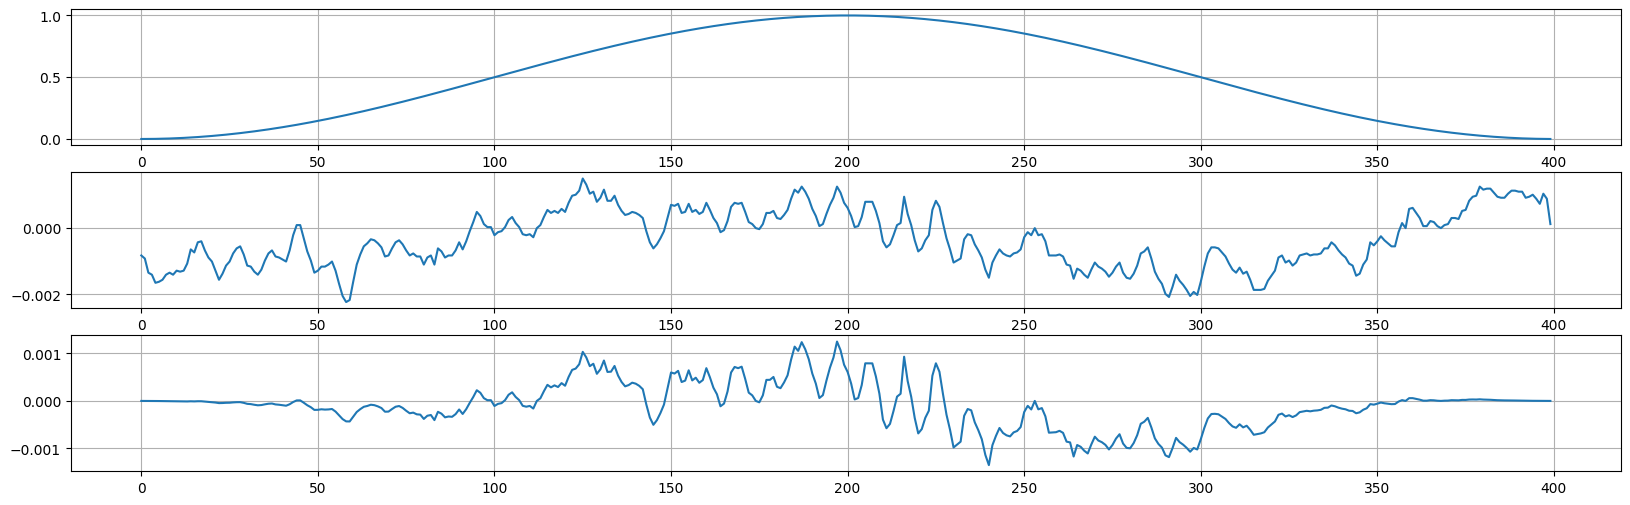

In [16]:
# window function
from scipy import signal

# 'hann' 윈도우 함수를 생성합니다. 이 윈도우는 FFT에 사용되는 400 샘플 길이로 설정됩니다.
window = signal.get_window('hann', 400, fftbins=True)
audio_win = audio_framed * window  # 프레임화된 오디오에 윈도우 함수를 요소별로 곱합니다.
idx = 1  # 시각화할 프레임의 인덱스 설정

plt.figure(figsize=(20, 6))

# 1) 윈도우 함수의 모양을 플롯
plt.subplot(3, 1, 1)
plt.plot(window)
plt.grid(True)

# 2) 선택한 인덱스의 원본 오디오 프레임 플롯
plt.subplot(3, 1, 2)
plt.plot(audio_framed[idx])
plt.grid(True)

# 3) 윈도우 함수가 적용된 오디오 프레임 플롯
plt.subplot(3, 1, 3)
plt.plot(audio_win[idx])
plt.grid(True)
plt.show()

<ipython-input-17-6997df715f30>:6: UserWarning: power_to_db was called on complex input so phase information will be discarded. To suppress this warning, call power_to_db(np.abs(D)**2) instead.
  log_S = librosa.power_to_db(S, ref=np.max) # 'ref=np.max'는 변환 과정에서 최대값을 기준으로 삼아 정규화합니다.


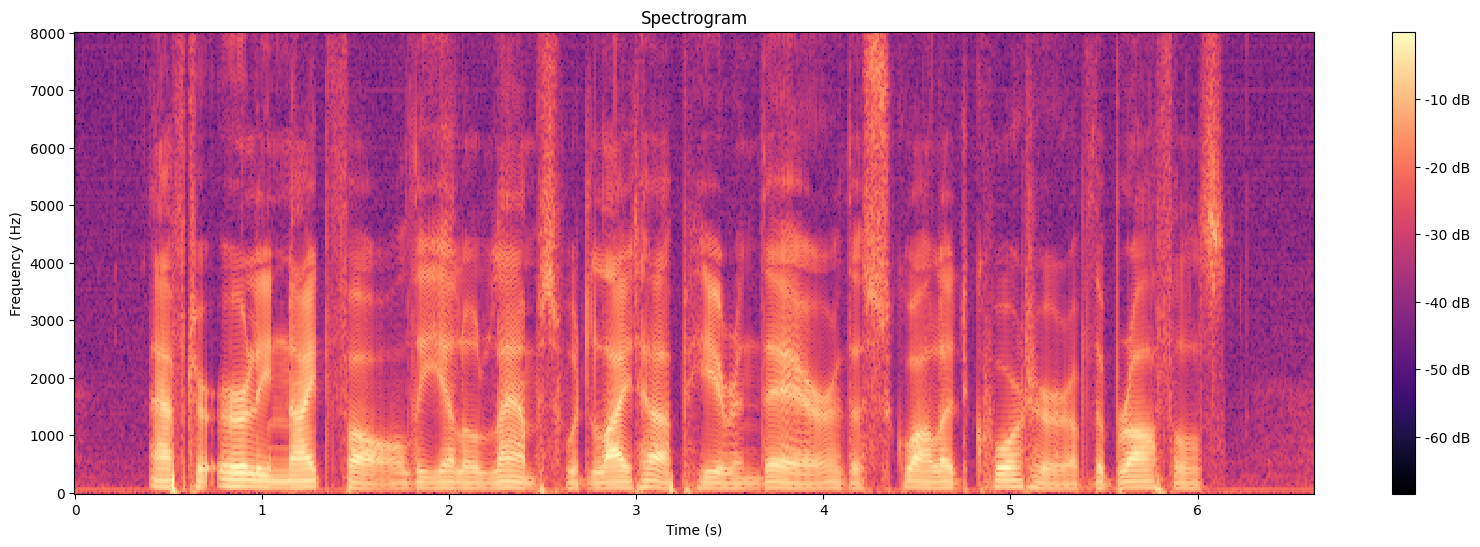

In [17]:
# STFT
# n_fft는 FFT 윈도우 크기, hop_length는 프레임 간의 샘플 수, win_length는 각 프레임의 윈도우 길이
S = librosa.core.stft(audio_np, n_fft=512, hop_length=160, win_length=400, window='hann', pad_mode='reflect')

# STFT 결과의 파워 스펙트럼을 데시벨 단위로 변환
log_S = librosa.power_to_db(S, ref=np.max) # 'ref=np.max'는 변환 과정에서 최대값을 기준으로 삼아 정규화합니다.

# 스펙트로그램 시각화
plt.figure(figsize=(20, 6))
librosa.display.specshow(log_S, sr=16000, hop_length=160, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.show()

- Mel Spectrogram: 사람의 청각 특성을 반영하기 위해 <ins>**Mel scale로 주파수를 변환한 Spectrogram**</ins>
- Mel scale: <ins>**낮은 주파수에서는 높은 해상도를, 높은 주파수에서는 상대적으로 낮은 해상도로 변환**</ins>하여 사람의 청각 특성을 반영
$$\text{m} = 2595 \times \log_{10} \left(1+\frac{f}{100}\right)$$
- Mel Filter bank: Mel scale에 기반하여 설계된 삼각형 필터들의 집합
- Mel Filter의 개수를 정하고 <ins>**Mel scale에서 Mel Filter의 개수만큼 등간격 구간**</ins>으로 나눔
- <ins>**각 구간의 중심값이 각 Mel Filter의 중심 주파수**</ins>가 되고, 중심 주파수에서 최대 값을 가지고 양 옆으로 감소하여 <ins>**인접한 필터의 중심 주파수에서 0이 되는 삼각형 필터**</ins>를 설계
- Mel Spectrogram의 단계
    1. <ins>**Spectogram**</ins> 생성
    2. 여러 개의 <ins>**Mel scale 기반 Filter bank를 적용**</ins>
    3. Mel Filter bank를 통과한 값에 <ins>**로그 스케일링**</ins>
    4. 계산된 값을 <ins>**시간에 따라 시각화**</ins>

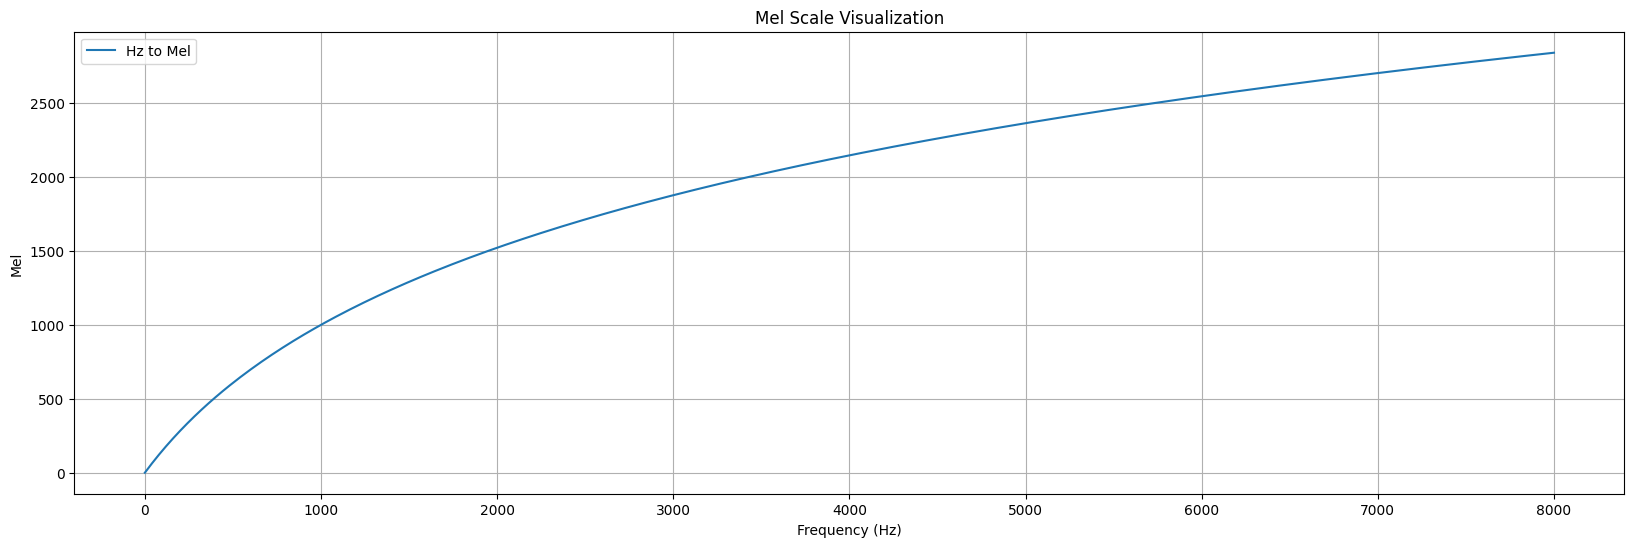

In [18]:
# Mel scale

def hz_to_mel(hz):
    # 헤르츠(Hz) 값을 멜 스케일로 변환하는 수식 적용
    return 2595 * np.log10(1 + hz / 700)

# 0Hz에서 8000Hz까지 400개의 주파수 값 생성
frequencies_hz = np.linspace(0, 8000, num=400)

# 생성된 주파수를 멜 스케일로 변환
mels = hz_to_mel(frequencies_hz)

plt.figure(figsize=(20, 6))
plt.plot(frequencies_hz, mels, label='Hz to Mel')
plt.title('Mel Scale Visualization')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mel')
plt.legend()
plt.grid(True)
plt.show()

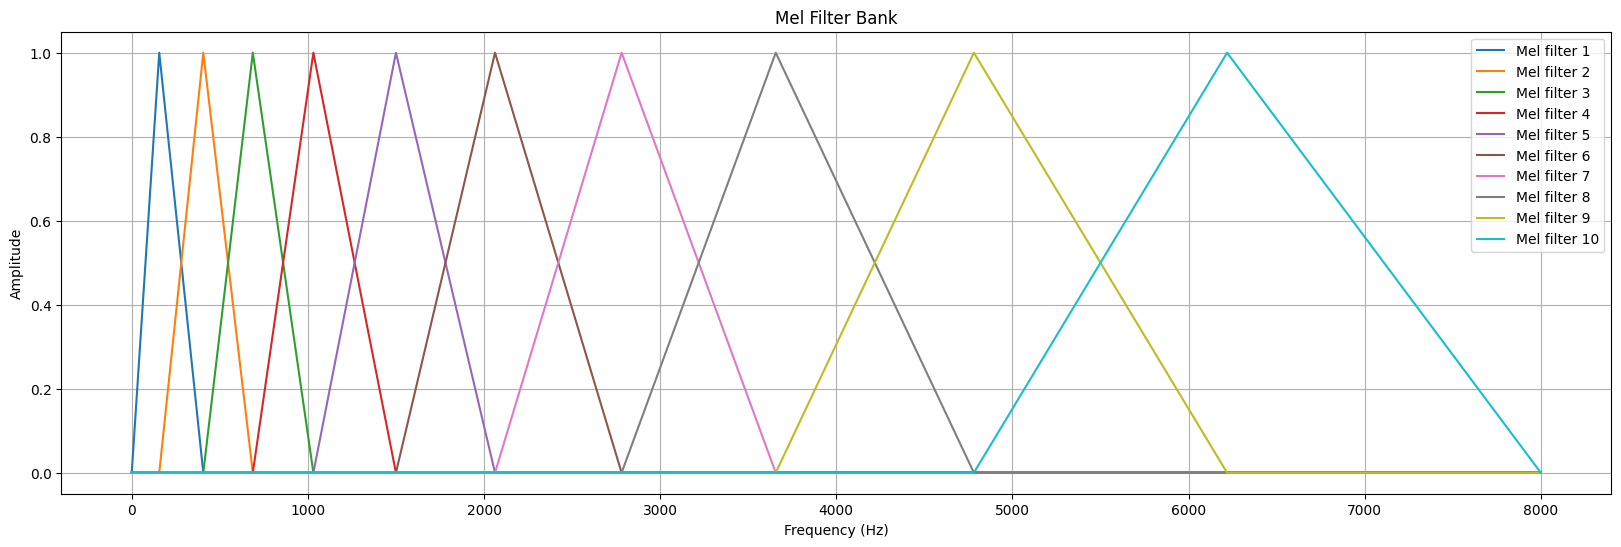

In [19]:
# Mel Filter bank
def create_mel_filterbank(num_filters, min_hz, max_hz, n_fft):
    # 주파수 단위를 Hz에서 Mel로 변환
    min_mel = hz_to_mel(min_hz)
    max_mel = hz_to_mel(max_hz)

    # 최소 및 최대 멜 사이에 선형적으로 배치된 멜 포인트 계산
    mels = np.linspace(min_mel, max_mel, num_filters + 2)

    # 멜 포인트를 Hz로 다시 변환
    hz_points = 700 * (10**(mels / 2595) - 1)

    # Hz를 FFT bin으로 변환
    fft_bins = np.floor((n_fft + 1) * hz_points / (max_hz * 2)).astype(int)

    # 필터뱅크 생성
    filterbank = np.zeros((num_filters, n_fft // 2 + 1))
    for n in range(1, num_filters + 1):
        filterbank[n-1, fft_bins[n-1]:fft_bins[n]] = (
            (np.arange(fft_bins[n-1], fft_bins[n]) - fft_bins[n-1]) / (fft_bins[n] - fft_bins[n-1])
        )
        filterbank[n-1, fft_bins[n]:fft_bins[n+1]] = (
            (fft_bins[n+1] - np.arange(fft_bins[n], fft_bins[n+1])) / (fft_bins[n+1] - fft_bins[n])
        )

    return filterbank, hz_points

# 매개변수 설정
num_filters = 10
min_hz = 0
max_hz = 8000
n_fft = 512

# 필터뱅크 생성
filterbank, hz_points = create_mel_filterbank(num_filters, min_hz, max_hz, n_fft)

# 시각화
plt.figure(figsize=(20, 6))
for n in range(num_filters):
    plt.plot(np.linspace(0, max_hz, n_fft // 2 + 1), filterbank[n], label=f'Mel filter {n + 1}')
plt.title('Mel Filter Bank')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

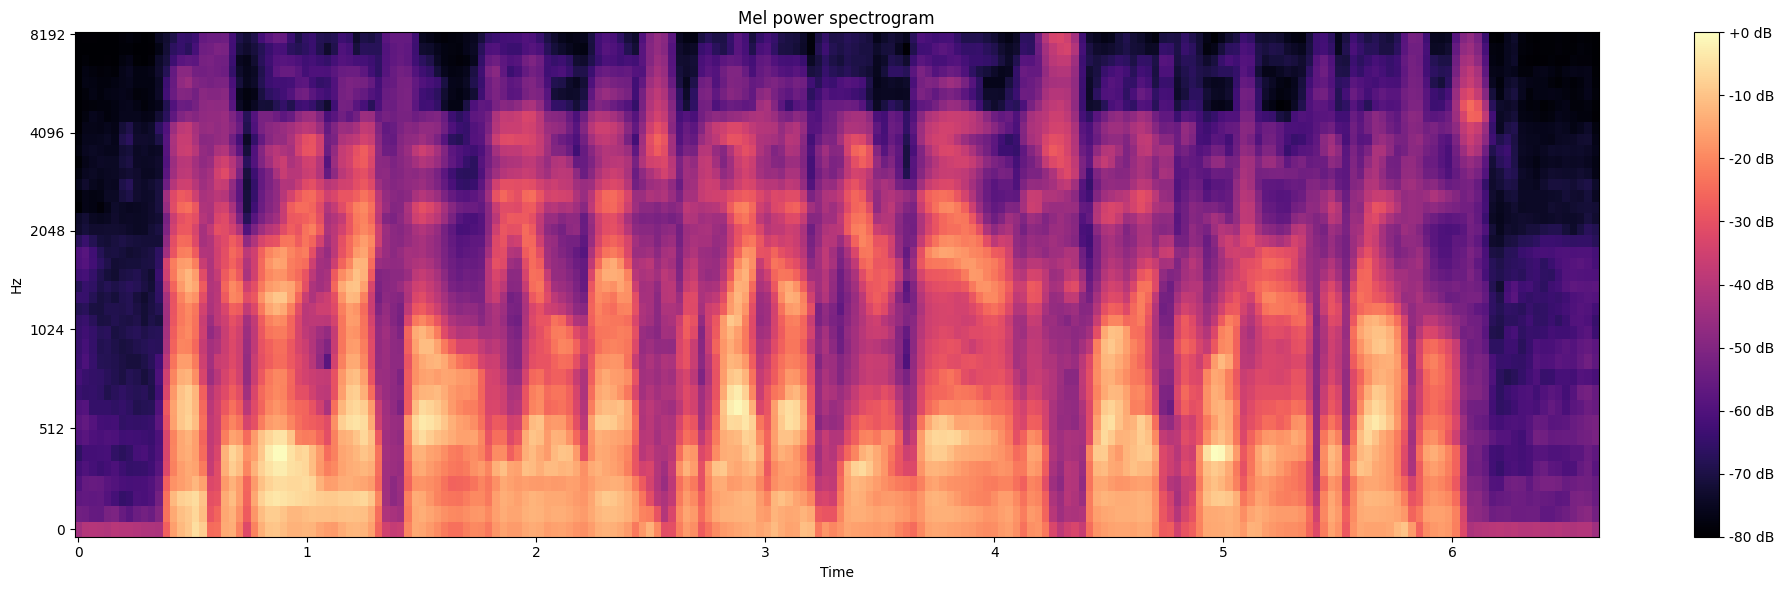

In [20]:
# Mel Spectroram
S = librosa.feature.melspectrogram(y=audio_np, sr=sr, n_mels=40) # 'y'는 오디오 데이터 배열, 'sr'은 샘플레이트, 'n_mels'은 멜 필터뱅크의 수

# 멜 스펙트로그램의 파워 값을 데시벨 단위로 변환합니다.
# 'ref=np.max'는 스펙트로그램의 최대 파워를 기준으로 사용하여 데시벨 스케일로 변환
log_S = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(20, 6))
librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel')
plt.title("Mel power spectrogram")
plt.colorbar(format='%+02.0f dB')
plt.tight_layout()

<ipython-input-21-992a234bcbd3>:6: UserWarning: power_to_db was called on complex input so phase information will be discarded. To suppress this warning, call power_to_db(np.abs(D)**2) instead.
  log_S = librosa.power_to_db(S, ref=np.max) # 'ref=np.max'는 변환 과정에서 최대값을 기준으로 삼아 정규화


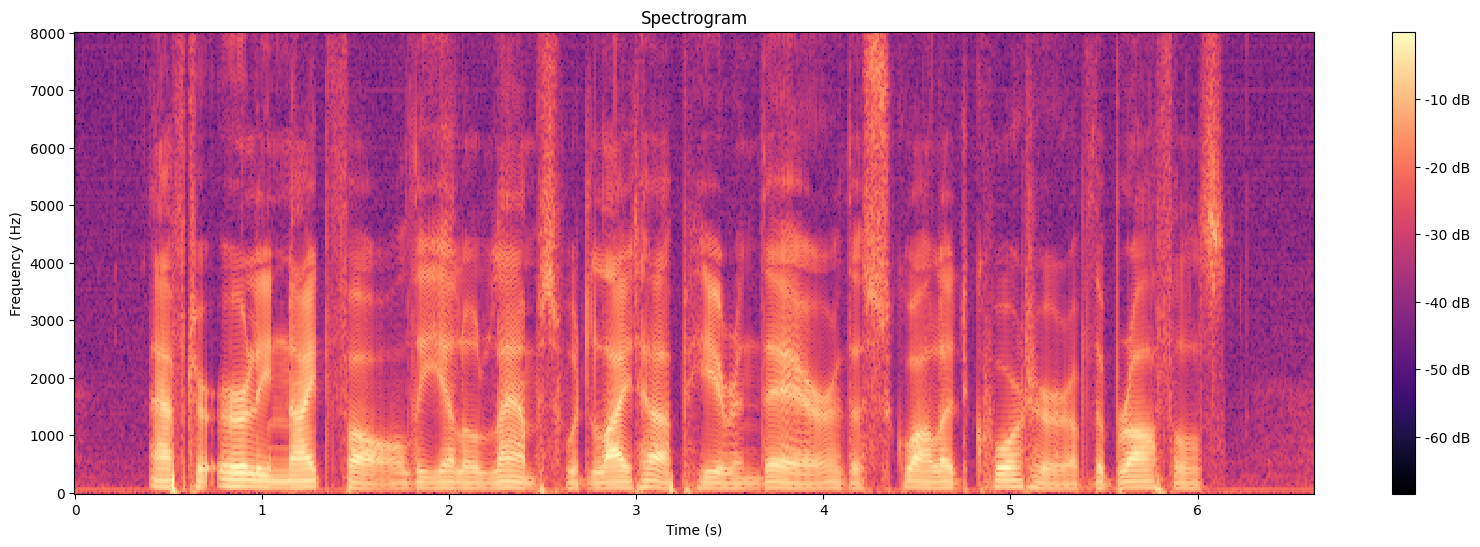

In [21]:
# STFT
# n_fft는 FFT 윈도우 크기, hop_length는 프레임 간의 샘플 수, win_length는 각 프레임의 윈도우 길이를 지정
S = librosa.core.stft(audio_np, n_fft=512, hop_length=160, win_length=400, window='hann', pad_mode='reflect')

# STFT 결과의 파워 스펙트럼을 데시벨 단위로 변환
log_S = librosa.power_to_db(S, ref=np.max) # 'ref=np.max'는 변환 과정에서 최대값을 기준으로 삼아 정규화

# # 스펙트로그램을 시각화
plt.figure(figsize=(20, 6))
librosa.display.specshow(log_S, sr=16000, hop_length=160, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.show()